# Multi-class Classification
using reuters dataset

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from keras import datasets, layers, Sequential, metrics
from keras.utils import to_categorical

## 1- Data Preparation

### Load and Inspect the Dataset

In [3]:
(train_data, train_labels), (test_data, test_labels) = datasets.reuters.load_data(num_words=10000)

In [4]:
print(train_data.shape)
print(train_labels.shape)
print(test_data.shape)
print(test_labels.shape)

(8982,)
(8982,)
(2246,)
(2246,)


In [5]:
word_index = datasets.reuters.get_word_index()
len(word_index)

30979

In [6]:
reverse_word_index = dict([(value, key) for (key, value) in word_index.items()])

decoded_review = " ".join([reverse_word_index.get(i - 3, "?") for i in train_data[0]])
print(decoded_review)

? ? ? said as a result of its december acquisition of space co it expects earnings per share in 1987 of 1 15 to 1 30 dlrs per share up from 70 cts in 1986 the company said pretax net should rise to nine to 10 mln dlrs from six mln dlrs in 1986 and rental operation revenues to 19 to 22 mln dlrs from 12 5 mln dlrs it said cash flow per share this year should be 2 50 to three dlrs reuter 3


In [8]:
print(train_labels[0])

3


In [9]:
print(np.unique(train_labels))

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45]


### Pre-processing

In [33]:
def multi_hot_encode(sequences, num_words):
    results = np.zeros((len(sequences), num_words))
    for i, sequence in enumerate(sequences):
        results[i][sequence] = 1.
    return results
    
x_train = multi_hot_encode(train_data, num_words=10000)
x_test = multi_hot_encode(test_data, num_words=10000)

x_train = x_train.astype('float32')
x_test = x_test.astype('float32')

y_train = train_labels.astype('float32')
y_test = test_labels.astype('float32')

print(x_train.shape)
print(x_test.shape)

(8982, 10000)
(2246, 10000)


In [34]:
y_train = to_categorical(train_labels)
y_test = to_categorical(test_labels)

print(y_train.shape)
print(y_test.shape)

(8982, 46)
(2246, 46)


### Prepare Validation Set

In [35]:
x_val = x_train[:1000]
partial_x_train = x_train[1000:]

y_val = y_train[:1000]
partial_y_train = y_train[1000:]

## 2- Model Design

In [36]:
model = Sequential([
    layers.Input(shape=x_train[0].shape),
    layers.Dense(64, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(46, activation='softmax'),
])

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                      │ (None, 64)                  │         640,064 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 46)                  │           2,990 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 647,214 (2.47 MB)

 Trainable params: 647,214 (2.47 MB)

 Non-trainable params: 0 (0.00 B)

## 3- Training

In [39]:
top_3_accuracy = metrics.TopKCategoricalAccuracy(k=3, name="top_3_accuracy")
model.compile(optimizer='adam', loss='categorical_crossentropy',
              metrics=['accuracy', top_3_accuracy])

In [40]:
history = model.fit(partial_x_train, partial_y_train,
                    epochs=20, batch_size=512,
                    validation_data=(x_val, y_val))

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.4371 - loss: 3.2055 - top_3_accuracy: 0.5859 - val_accuracy: 0.5300 - val_loss: 2.3765 - val_top_3_accuracy: 0.6790
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6149 - loss: 1.8623 - top_3_accuracy: 0.7514 - val_accuracy: 0.6580 - val_loss: 1.5311 - val_top_3_accuracy: 0.7720
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7206 - loss: 1.2682 - top_3_accuracy: 0.8297 - val_accuracy: 0.7350 - val_loss: 1.2231 - val_top_3_accuracy: 0.8370
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7924 - loss: 0.9666 - top_3_accuracy: 0.8807 - val_accuracy: 0.7720 - val_loss: 1.0644 - val_top_3_accuracy: 0.8770
Epoch 5/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8450 - loss: 0.7559 - top_3_accuracy: 0.9166 - val_accuracy: 0.7900 - val_loss: 0.9848 - val_top_3_accuracy: 0.8970
Epoch 6/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8809 - loss: 0.5885 - top_3_ac

## 4- Evaluation

In [42]:
test_loss, test_acc, test_top3_acc = model.evaluate(x_test, y_test, verbose=0)
print(f'Test Loss: {test_loss:.4f}')
print(f'Test Accuracy: {test_acc:.4f}')
print(f'Test Top3 Accuracy: {test_top3_acc:.4f}')

Test Loss: 1.1099
Test Accuracy: 0.7921
Test Top3 Accuracy: 0.9087


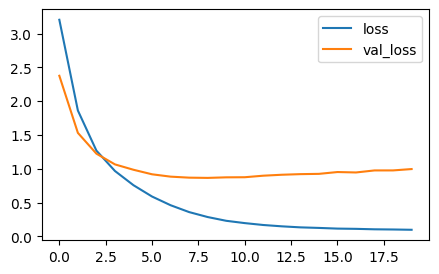

In [43]:
history_df = pd.DataFrame(history.history)
history_df[['loss', 'val_loss']].plot(figsize=(5,3))
plt.show()

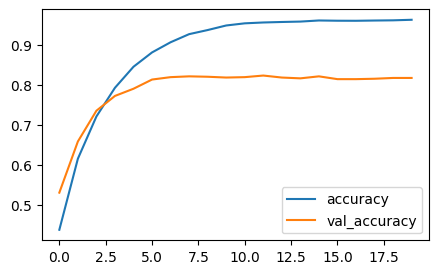

In [44]:
history_df[['accuracy', 'val_accuracy']].plot(figsize=(5,3))
plt.show()

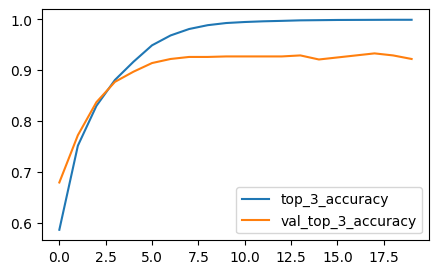

In [45]:
history_df[['top_3_accuracy', 'val_top_3_accuracy']].plot(figsize=(5,3))
plt.show()

In [54]:
y_preds = model.predict(x_test)
y_classes = np.argmax(y_preds, axis=1)

71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [50]:
y_preds[0]

array([2.7901751e-06, 5.4810022e-07, 2.3983153e-08, 9.7530794e-01,
       2.2674806e-02, 3.1822898e-09, 6.6004233e-08, 1.6208134e-05,
       3.6233748e-04, 2.5412030e-06, 1.5576472e-06, 3.0533938e-05,
       2.7094986e-06, 8.4906769e-06, 1.3568562e-06, 4.2799206e-07,
       7.8298071e-06, 3.9315551e-06, 2.0550807e-08, 6.0131028e-04,
       8.6125091e-04, 7.0209069e-05, 2.7790611e-08, 2.1376646e-07,
       6.9714412e-07, 4.9745659e-06, 3.8319958e-10, 3.6487315e-08,
       3.1223184e-08, 1.1475217e-05, 6.2873778e-06, 1.1394361e-06,
       1.3518412e-07, 3.0471291e-08, 3.7065545e-06, 3.4548921e-06,
       4.6242853e-06, 2.2600739e-06, 3.6773645e-07, 5.9097215e-07,
       1.4451954e-06, 1.1187506e-06, 2.3446672e-08, 1.6561488e-08,
       5.7370201e-08, 3.6707806e-07], dtype=float32)

In [55]:
y_classes[0]

np.int64(3)